<a href="https://colab.research.google.com/github/Dathu-03184/DL_Lab-Programs/blob/main/07%20program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

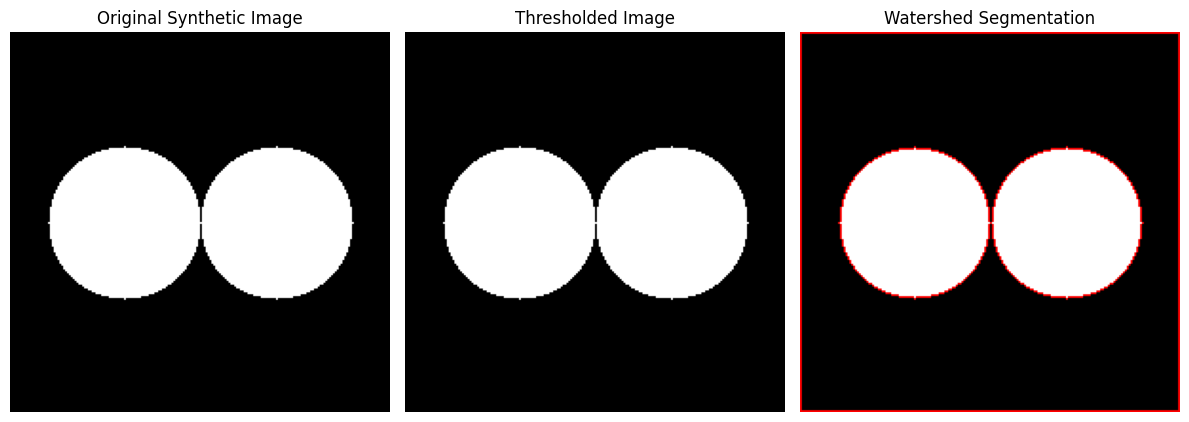

In [1]:
# 07 Program
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Create synthetic image with overlapping circles
img = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(img, (60, 100), 40, 255, -1)
cv2.circle(img, (140, 100), 40, 255, -1)

# Convert to color image for visualization
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# 2️⃣ Noise removal and thresholding
_, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# 3️⃣ Sure background and sure foreground
sure_bg = cv2.dilate(opening, kernel, iterations=3)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.5*dist_transform.max(), 255, 0)

# 4️⃣ Unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# 5️⃣ Marker labelling
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1  # so that background is not 0
markers[unknown==255] = 0

# 6️⃣ Apply Watershed
markers = cv2.watershed(img_color, markers)
img_color[markers == -1] = [0, 0, 255]  # mark boundaries in red

# 7️⃣ Visualization
plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Synthetic Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(thresh, cmap='gray')
plt.title("Thresholded Image")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
plt.title("Watershed Segmentation")
plt.axis('off')

plt.tight_layout()
plt.show()
